In [19]:
from langchain_openai import ChatOpenAI


In [20]:
import os

In [21]:
os.environ["OPENAI_API_BASE"] = "http://127.0.0.1:1234/v1"
os.environ["OPENAI_API_KEY"] = "lm_studio"

In [22]:
llm = ChatOpenAI(model="qwen3-1.7b@q6_k")

In [23]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Requete qui optimise la recherche web.")
    justification: str = Field(None, description="Pourquoi cette requete est-elle importante pour la demande de l'utilisateur ?")

structured_llm = llm.with_structured_output(SearchQuery)

output = structured_llm.invoke("Comment le calcium est-il absorbé par le corps humain ?")

print(output.search_query)
print(output.justification)

calcium absorption
Le calcium est essentiel pour la croissance osseuse et la santé musculaire, mais son absorption dépend de plusieurs facteurs.


## Pattern 1: Prompt Engeneering

In [24]:
from langgraph.graph import END, START, StateGraph

In [25]:
from typing_extensions import TypedDict, cast

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

### Noeuds

#### 1. Générer la blague 

In [26]:
def generate_joke(state: State) -> State:
    """Premier appel LLM pour générer une blague à partir du sujet."""
    msg = llm.invoke(f"Ecris une courte blague sur {state['topic']}")
    state['joke'] = f"{msg.content}"
    return state

#### 2. Vérifier s'il y a une punchline

In [27]:
def check_punchline(state: State) -> str:
    """Fonction pour vérifier si la blague a une punchline."""
    # si la blague contient "?" ou "!"
    if "?" in state['joke'] or "!" in state['joke']:
        return "Pass"
    return "Fail"

#### 3. Améliorer la blague

In [28]:
def improve_joke(state: State) -> State:
    """Deuxième appel LLM pour améliorer la blague."""
    msg = llm.invoke(f"Rend la blague plus amusante en ajoutant des jeux de mots : {state['joke']}")
    state['improved_joke'] = f"{msg.content}"
    return state

#### 4. Finalisation de la blague

In [29]:
def polish_joke(state: State) -> State:
    """Troisième appel LLM pour finaliser la blague."""
    msg = llm.invoke(f"Ajoute une surprise à  cette blague : {state['improved_joke']}")
    state['final_joke'] = f"{msg.content}"
    return state

## Construction du Workflow

In [30]:
workflow = StateGraph(State)

#### 1. Ajout  des noeuds

In [31]:
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

#### 2. Connecter les noeuds

In [32]:
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

#### 3. Compiler

In [33]:
chain = workflow.compile()

#### 4. Show workflow

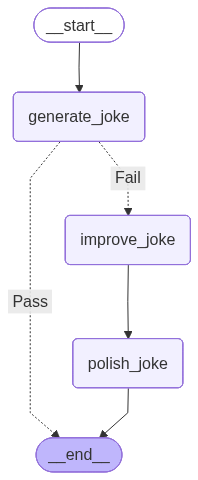

In [34]:
from IPython.display import Image, display
display(Image(chain.get_graph().draw_mermaid_png()))

## Exemple

In [35]:
state = chain.invoke(State({"topic": "les chats", "joke": "", "improved_joke": "", "final_joke": ""}))

print("initial joke: ")
print(state['joke'])
print("\n---------\n")

if state["improved_joke"]:
    print("improved joke: ")
    print(state['improved_joke'])
    print("\n---------\n")

    print("Final joke: ")
    print(state['final_joke'])
else:
    print("Final joke: ")
    print(state['joke'])

BadRequestError: Error code: 400 - {'error': 'Model unloaded.'}

## Pattern 2: Parallelization

- Example : à partir d'un topic, générer une blague, une blague, une histoire

### Cas d'usage:
- Découper en sous-tâches et les éxecuter en parallèle afin d'améliorer la vitesse
- Exécuter des tâches plusieurs foispour vérifier les différentes sorties